# Task 1 — Data Cleaning and Validation

Objective:
Validate all datasets and detect data quality issues before analytics.

Checks:
- Missing values
- Duplicate IDs
- Invalid dates
- Negative values
- Invalid status values
- Inconsistent flight times
- Incorrect payment calculations
- Impossible study progress
- Aircraft downtime issues
- Flight training inconsistencies

## Import Libraries

In [6]:
import pandas as pd
import numpy as np

## Load Datasets

In [7]:
sorties = pd.read_csv("../data/sorties.csv")

aircraft = pd.read_csv("../data/aircraft.csv")

cadets = pd.read_csv("../data/cadets.csv")

instructors = pd.read_csv("../data/instructors.csv")

toga = pd.read_csv("../data/toga_study.csv")

payments = pd.read_csv("../data/payments.csv")

## Validation Setup
Store all validation results.

In [8]:
validation=[]

def record(issue,dataset,count,details):

    validation.append({
        "Issue":issue,
        "Dataset":dataset,
        "Count":count,
        "Details":details
    })

## Check 1 — Missing Values

In [ ]:
for name,df in {
"sorties":sorties,
"aircraft":aircraft,
"cadets":cadets,
"instructors":instructors,
"toga":toga,
"payments":payments
}.items():

    missing=df.isnull().sum()

    missing=missing[missing>0]

    if len(missing)>0:

        record(
            "Missing Values",
            name,
            len(missing),
            missing.to_dict()
        )

## Check 2 — Duplicate IDs

In [9]:
checks=[

(sorties,"sortie_id"),

(aircraft,"aircraft_id"),

(cadets,"cadet_id"),

(instructors,"instructor_id")

]

for df,col in checks:

    dup=df[col].duplicated().sum()

    if dup>0:

        record(
            "Duplicate IDs",
            col,
            dup,
            "Duplicate IDs found"
        )

## Check 3 — Invalid Dates

In [10]:
date_cols=[

"scheduled_start",
"scheduled_end",
"actual_start",
"actual_end"

]

for col in date_cols:

    sorties[col]=pd.to_datetime(
        sorties[col],
        errors="coerce"
    )

bad=sorties[date_cols].isnull().sum()

bad=bad[bad>0]

if len(bad)>0:

    record(
        "Invalid Dates",
        "sorties",
        len(bad),
        bad.to_dict()
    )

## Check 4 — Negative Values

In [11]:
columns=[

(cadets,"total_flown_hours"),

(payments,"paid_amount"),

(payments,"outstanding_amount"),

(aircraft,"maintenance_downtime_hours")

]

for df,col in columns:

    neg=(df[col]<0).sum()

    if neg>0:

        record(
            "Negative Values",
            col,
            neg,
            "Negative detected"
        )

## Check 5 — Invalid Status Values

In [13]:
allowed=[

"completed",
"cancelled"

]

bad=~sorties["status"].isin(allowed)

count=bad.sum()

if count>0:

    record(
        "Invalid Status",
        "sorties",
        count,
        "Unexpected values"
    )

## Check 6 — Inconsistent Flight Times

In [14]:
bad1=sorties[
(sorties["status"]=="completed")
&
(
sorties["actual_start"].isnull()
|
sorties["actual_end"].isnull()
)
]

record(
"Completed Missing Times",
"sorties",
len(bad1),
"Completed without times"
)

bad2=sorties[
(sorties["status"]=="cancelled")
&
(
sorties["actual_start"].notnull()
|
sorties["actual_end"].notnull()
)
]

record(
"Cancelled With Flight",
"sorties",
len(bad2),
"Cancelled but has times"
)

## Check 7 — Delay Validation

In [15]:
delay=(
(
sorties["actual_start"]
-
sorties["scheduled_start"]
)
.dt.total_seconds()/60
)

bad=(
delay
!=
sorties["delay_minutes"]
)

record(
"Delay Mismatch",
"sorties",
bad.sum(),
"Delay mismatch"
)

## Check 8 — Payment Validation

In [16]:
calc=(
payments["invoiced_amount"]
-
payments["paid_amount"]
)

bad=(
calc
!=
payments["outstanding_amount"]
)

record(
"Payment Error",
"payments",
bad.sum(),
"Outstanding incorrect"
)

## Check 9 — Study Validation

In [17]:
bad=(
toga["chapters_completed"]
>
toga["total_chapters"]
)

record(
"Study >100%",
"toga",
bad.sum(),
"Progress exceeded"
)

## Check 10 — Aircraft Validation

In [18]:
bad=(
aircraft[
"maintenance_downtime_hours"
]
>
aircraft[
"total_available_hours"
]
)

record(
"Downtime Issue",
"aircraft",
bad.sum(),
"Downtime exceeded"
)

high=(
aircraft[
"defect_count"
]
>
7
)

record(
"High Defects",
"aircraft",
high.sum(),
"High defect count"
)

## Check 11 — Flight Without Study

In [19]:
study=toga["cadet_id"].unique()

bad=cadets[
(
cadets[
"total_flown_hours"
]>0
)
&
(
~cadets[
"cadet_id"
].isin(study)
)
]

record(
"No Study Activity",
"cadets",
len(bad),
"Flight but no study"
)

## Validation Results

In [20]:
report=pd.DataFrame(validation)

report

,Issue,Dataset,Count,Details
0,Invalid Dates,sorties,2,"{'actual_start': 30, 'actual_end': 30}"
1,Completed Missing Times,sorties,1,Completed without times
2,Cancelled With Flight,sorties,0,Cancelled but has times
3,Delay Mismatch,sorties,31,Delay mismatch
4,Payment Error,payments,1,Outstanding incorrect
5,Study >100%,toga,1,Progress exceeded
6,Downtime Issue,aircraft,0,Downtime exceeded
7,High Defects,aircraft,2,High defect count
8,No Study Activity,cadets,1,Flight but no study


## Export Validation Report

In [22]:
report.to_markdown(
"../reports/data_quality_report.md",
index=False
)

print(
"Task 1 completed"
)

Task 1 completed


# Task 2 — Skynet Operations Analytics

Objective:
Evaluate operational efficiency of the Flight Training Organisation (FTO).

Sections:
1. Aircraft Utilization
2. Instructor Utilization
3. Dispatch Reliability

## 1. Aircraft Utilization

In [23]:
completed=sorties[
sorties["status"]=="completed"
].copy()

completed.shape

(137, 13)

### Calculate Actual Flown Hours

In [24]:
completed["actual_flown_hours"]=(
completed["actual_end"]
-
completed["actual_start"]
).dt.total_seconds()/3600

completed[
[
"aircraft_id",
"actual_flown_hours"
]
].head()

,aircraft_id,actual_flown_hours
0,A001,2.0
1,A002,2.0
2,A002,2.0
3,A001,1.5
4,A003,1.5


### Aircraft Utilization
Formula:

actual_flown_hours / total_available_hours

In [25]:
aircraft_hours=(
completed
.groupby(
"aircraft_id"
)
[
"actual_flown_hours"
]
.sum()
.reset_index()
)

aircraft_util=(
aircraft
.merge(
aircraft_hours,
on="aircraft_id",
how="left"
)
)

aircraft_util[
"actual_flown_hours"
]=(
aircraft_util[
"actual_flown_hours"
]
.fillna(0)
)

aircraft_util[
"utilization"
]=(
aircraft_util[
"actual_flown_hours"
]
/
aircraft_util[
"total_available_hours"
]
)

aircraft_util

,aircraft_id,registration,type,base_id,total_available_hours,maintenance_downtime_hours,defect_count,actual_flown_hours,utilization
0,A001,VT-ABC,C172,B01,180,18,2,42.583333,0.236574
1,A002,VT-SKY,PA28,B01,165,22,4,49.000000,0.296970
2,A003,VT-GRN,DA40,B01,170,20,3,31.000000,0.182353
3,A004,VT-AIR,C172,B02,150,55,10,59.500000,0.396667
4,A005,VT-RED,PA28,B02,140,48,8,55.500000,0.396429


### Underutilized Aircraft

In [26]:
underutilized=aircraft_util[
aircraft_util[
"utilization"
]
<
0.30
]

underutilized

,aircraft_id,registration,type,base_id,total_available_hours,maintenance_downtime_hours,defect_count,actual_flown_hours,utilization
0,A001,VT-ABC,C172,B01,180,18,2,42.583333,0.236574
1,A002,VT-SKY,PA28,B01,165,22,4,49.000000,0.296970
2,A003,VT-GRN,DA40,B01,170,20,3,31.000000,0.182353


### High Defect Aircraft

In [27]:
high_defect=aircraft[
aircraft[
"defect_count"
]
>
7
]

high_defect

,aircraft_id,registration,type,base_id,total_available_hours,maintenance_downtime_hours,defect_count
3,A004,VT-AIR,C172,B02,150,55,10
4,A005,VT-RED,PA28,B02,140,48,8


### Maintenance Downtime Impact

In [28]:
aircraft_util[
"downtime_percent"
]=(
aircraft_util[
"maintenance_downtime_hours"
]
/
aircraft_util[
"total_available_hours"
]
)*100

aircraft_util[
[
"aircraft_id",
"downtime_percent"
]
]

,aircraft_id,downtime_percent
0,A001,10.000000
1,A002,13.333333
2,A003,11.764706
3,A004,36.666667
4,A005,34.285714


## 2. Instructor Utilization

### Calculate Instructor Utilization
Formula:

flight_hours / duty_hours

In [30]:
instructors["utilization"]=(
instructors["total_flight_hours"]
/
instructors["total_duty_hours"]
)

instructors[
[
"instructor_id",
"name",
"total_duty_hours",
"total_flight_hours",
"utilization"
]
]

,instructor_id,name,total_duty_hours,total_flight_hours,utilization
0,I001,Capt Rao,160,118,0.737500
1,I002,Capt Menon,145,88,0.606897
2,I003,Capt Sharma,130,74,0.569231
3,I004,Capt Pillai,120,31,0.258333


### Overloaded Instructors

In [33]:
overloaded = instructors[
    instructors["utilization"] > 0.70
]

overloaded

,instructor_id,name,base_id,aircraft_qualified,total_duty_hours,total_flight_hours,utilization
0,I001,Capt Rao,B01,"C172,DA40",160,118,0.7375


## 3. Dispatch Reliability

### Overall Dispatch Metrics

In [41]:
total_sorties = len(sorties)

completed_sorties = (
sorties["status"]
==
"completed"
).sum()

cancelled_sorties = (
sorties["status"]
==
"cancelled"
).sum()

delayed_sorties = (
sorties["delay_minutes"]
>
0
).sum()

completion_rate = (
completed_sorties
/
total_sorties
)*100

cancellation_rate = (
cancelled_sorties
/
total_sorties
)*100

avg_delay = (
sorties[
"delay_minutes"
]
.mean()
)

dispatch_summary = pd.DataFrame({

"Metric":[
"Total Sorties",
"Completed",
"Cancelled",
"Delayed",
"Completion Rate",
"Cancellation Rate",
"Average Delay"
],

"Value":[
total_sorties,
completed_sorties,
cancelled_sorties,
delayed_sorties,
completion_rate,
cancellation_rate,
avg_delay
]

})

dispatch_summary

,Metric,Value
0,Total Sorties,166.000000
1,Completed,137.000000
2,Cancelled,29.000000
3,Delayed,78.000000
4,Completion Rate,82.530120
5,Cancellation Rate,17.469880
6,Average Delay,16.150602


### Top Cancellation Reasons

In [43]:
cancelled = sorties[
    sorties["status"] == "cancelled"
]

possible = [
    "cancellation_reason",
    "cancel_reason",
    "reason"
]

found = None

for col in possible:

    if col in cancelled.columns:

        found = col
        break

if found:

    cancel_reason = (
        cancelled[found]
        .value_counts()
        .reset_index()
    )

else:

    cancel_reason = (
        pd.DataFrame({
            "Result":[
                "No cancellation reason column"
            ]
        })
    )

cancel_reason

,cancel_reason,count
0,Weather,12
1,Aircraft Defect,12
2,Cadet Unavailable,5


### Delay Trend by Base
Analyse average delay across training bases.

In [45]:
delay_base = (

sorties

.groupby(
"base_id"
)

[
"delay_minutes"
]

.mean()

.reset_index()

.sort_values(
"delay_minutes",
ascending=False
)

)

delay_base

,base_id,delay_minutes
0,B01,17.743590
1,B02,14.738636


### Delay Trend by Lesson Type
Analyse average delay across lesson categories.

In [46]:
delay_lesson = (

sorties

.groupby(
"lesson_type"
)

[
"delay_minutes"
]

.mean()

.reset_index()

.sort_values(
"delay_minutes",
ascending=False
)

)

delay_lesson

,lesson_type,delay_minutes
3,Instrument,19.454545
1,Cross Country,17.837838
4,Navigation,16.783784
2,General Handling,15.548387
0,Circuit,9.857143


### Aircraft Operational Review Candidates
Flag aircraft requiring operational attention.

In [47]:
review = aircraft_util[

(
aircraft_util[
"utilization"
]
<
0.30
)

|

(
aircraft_util[
"defect_count"
]
>
7
)

|

(
aircraft_util[
"downtime_percent"
]
>
30
)

]

review[
[
"aircraft_id",
"utilization",
"defect_count",
"downtime_percent"
]
]

,aircraft_id,utilization,defect_count,downtime_percent
0,A001,0.236574,2,10.000000
1,A002,0.296970,4,13.333333
2,A003,0.182353,3,11.764706
3,A004,0.396667,10,36.666667
4,A005,0.396429,8,34.285714


## Export Task 2 Report
Generate Skynet Operations report.

In [48]:
with open(
"../reports/skynet_operations_analysis.md",
"w",
encoding="utf-8"
) as f:

    f.write(
"# Task 2 — Skynet Operations Analytics\n\n"
    )

    f.write(
"## Dispatch Summary\n\n"
    )

    f.write(
dispatch_summary.to_markdown(
index=False
)
    )

print(
"Task 2 completed"
)

Task 2 completed


# Task 3 — Training Progress Analytics

Objective:
Analyse cadet training progression, completion readiness, and delay risk.

Metrics:
1. Progress Percentage
2. Remaining Flight Hours
3. Average Flying Rate
4. Completion Risk
5. Delay Risk
6. Lesson Bottlenecks
7. Instructor/Cadet Bottlenecks

In [2]:
import pandas as pd

sorties=pd.read_csv("../data/sorties.csv")

aircraft=pd.read_csv("../data/aircraft.csv")

cadets=pd.read_csv("../data/cadets.csv")

instructors=pd.read_csv("../data/instructors.csv")

toga=pd.read_csv("../data/toga_study.csv")

payments=pd.read_csv("../data/payments.csv")

print("Loaded")

Loaded


## 1. Cadet Progress Percentage

In [5]:
cadets["progress_percent"]=(

cadets[
"total_flown_hours"
]

/

cadets[
"total_required_hours"
]

)*100

cadets[
[
"cadet_id",
"course",
"total_flown_hours",
"total_required_hours",
"progress_percent"
]
]

,cadet_id,course,total_flown_hours,total_required_hours,progress_percent
0,C001,PPL,22.7,45,50.444444
1,C002,PPL,24.0,45,53.333333
2,C003,PPL,26.5,45,58.888889
3,C004,PPL,20.9,45,46.444444
4,C005,PPL,24.0,45,53.333333
5,C006,CPL,96.6,200,48.300000
6,C007,CPL,109.2,200,54.600000
7,C008,PPL,23.7,45,52.666667
8,C009,CPL,85.6,200,42.800000
9,C010,PPL,14.4,45,32.000000


## 2. Remaining Flight Hours

In [6]:
cadets[
"remaining_hours"
]=(

cadets[
"total_required_hours"
]

-

cadets[
"total_flown_hours"
]

)

cadets[
[
"cadet_id",
"remaining_hours"
]
]

,cadet_id,remaining_hours
0,C001,22.3
1,C002,21.0
2,C003,18.5
3,C004,24.1
4,C005,21.0
5,C006,103.4
6,C007,90.8
7,C008,21.3
8,C009,114.4
9,C010,30.6


## 3. Average Flying Rate

In [7]:
avg_rate=(

sorties

.groupby(
"cadet_id"
)

.size()

.reset_index(
name="sorties_count"
)

)

avg_rate

,cadet_id,sorties_count
0,C001,10
1,C002,14
2,C003,11
3,C004,13
4,C005,10
5,C006,10
6,C007,10
7,C008,12
8,C009,10
9,C010,12


## 4. Estimated Completion Risk

In [8]:
cadets[
"completion_risk"
]="Low"

cadets.loc[
cadets[
"progress_percent"
]
<
40,

"completion_risk"

]="High"

cadets.loc[
(
cadets[
"progress_percent"
]
>=40
)

&
(
cadets[
"progress_percent"
]
<
70
),

"completion_risk"

]="Medium"

cadets[
[
"cadet_id",
"progress_percent",
"completion_risk"
]
]

,cadet_id,progress_percent,completion_risk
0,C001,50.444444,Medium
1,C002,53.333333,Medium
2,C003,58.888889,Medium
3,C004,46.444444,Medium
4,C005,53.333333,Medium
5,C006,48.300000,Medium
6,C007,54.600000,Medium
7,C008,52.666667,Medium
8,C009,42.800000,Medium
9,C010,32.000000,High


## 5. Cadets at Risk of Delay

In [10]:
delay=(

sorties

.groupby(
"cadet_id"
)

[
"delay_minutes"
]

.mean()

)

risk_delay = delay[
delay
>
20
]

risk_delay

cadet_id
C005    23.400000
C009    28.600000
C015    26.363636
Name: delay_minutes, dtype: float64

## 6. Lesson Types with Higher Cancellation / Delay
Identify lesson categories causing training slowdowns.

In [11]:
lesson_analysis = (

sorties

.groupby(
"lesson_type"
)

.agg({

"delay_minutes":"mean",

"status":lambda x:
(
x=="cancelled"
).sum()

})

.reset_index()

)

lesson_analysis.columns=[

"lesson_type",

"avg_delay",

"cancelled_count"

]

lesson_analysis=lesson_analysis.sort_values(

[
"cancelled_count",
"avg_delay"
],

ascending=False

)

lesson_analysis

,lesson_type,avg_delay,cancelled_count
3,Instrument,19.454545,7
2,General Handling,15.548387,7
0,Circuit,9.857143,7
4,Navigation,16.783784,5
1,Cross Country,17.837838,3


## 7. Instructor / Cadet Bottlenecks
Identify instructor concentration and workload imbalance.

In [12]:
bottleneck=(

sorties

.groupby(
"instructor_id"
)

[
"cadet_id"
]

.nunique()

.reset_index()

)

bottleneck.columns=[

"instructor_id",

"cadet_count"

]

bottleneck["bottleneck"]=(
bottleneck[
"cadet_count"
]
>
3
)

bottleneck

,instructor_id,cadet_count,bottleneck
0,I001,7,True
1,I002,7,True
2,I003,8,True
3,I004,8,True


## 8. Generate Cadet Training Risk Insights

Combine training progress, payments, and study readiness to identify cadets likely to face completion delays.

In [13]:
risk = cadets.merge(
payments,
on="cadet_id",
how="left"
)

risk.columns

Index(['cadet_id', 'name', 'course', 'home_base', 'total_required_hours',
       'total_flown_hours', 'enrollment_date', 'progress_percent',
       'remaining_hours', 'completion_risk', 'invoiced_amount', 'paid_amount',
       'outstanding_amount', 'last_payment_date'],
      dtype='str')

In [14]:
risk["training_risk"]="Low"

risk.loc[
risk["progress_percent"]<40,
"training_risk"
]="High"

risk.loc[
(
risk["progress_percent"]>=40
)
&
(
risk["progress_percent"]<70
),
"training_risk"
]="Medium"

risk[
[
"cadet_id",
"progress_percent",
"training_risk"
]
]

,cadet_id,progress_percent,training_risk
0,C001,50.444444,Medium
1,C002,53.333333,Medium
2,C003,58.888889,Medium
3,C004,46.444444,Medium
4,C005,53.333333,Medium
5,C006,48.300000,Medium
6,C007,54.600000,Medium
7,C008,52.666667,Medium
8,C009,42.800000,Medium
9,C010,32.000000,High


## Example Insight Generation

In [15]:
high = risk[
risk[
"training_risk"
]
==
"High"
]

high[
[
"cadet_id",
"progress_percent",
"training_risk"
]
]

,cadet_id,progress_percent,training_risk
9,C010,32.0,High
12,C013,22.0,High
13,C014,16.0,High
14,C015,22.5,High


## Export Task 3 Report

In [16]:
with open(
"../reports/training_progress_analysis.md",
"w",
encoding="utf-8"
) as f:

    f.write(
"# Task 3 — Training Progress Analytics\n\n"
    )

    f.write(
cadets[
[
"cadet_id",
"progress_percent",
"remaining_hours",
"completion_risk"
]
].to_markdown(
index=False
)
    )

print(
"training_progress_analysis.md created"
)

training_progress_analysis.md created


# Task 4 — TOGA Study Intelligence

Objective:
Analyse cadet learning behaviour and generate study intelligence.

Metrics:
1. Subject Progress
2. Weak Subjects
3. Quiz Performance
4. Inactivity Risk
5. Study Readiness
6. Study vs Flight Relationship
7. Instructor Intervention

## 1. Subject Progress

In [17]:
toga["progress_percent"]=(

toga[
"chapters_completed"
]

/

toga[
"total_chapters"
]

)*100

toga[
[
"cadet_id",
"subject",
"progress_percent"
]
]

,cadet_id,subject,progress_percent
0,C001,Human Performance,65.000000
1,C001,Navigation,76.666667
2,C001,Air Regulations,60.714286
3,C002,Air Regulations,71.428571
4,C002,Aircraft Technical,77.272727
5,C002,Navigation,76.666667
6,C003,Meteorology,60.000000
7,C003,Human Performance,55.000000
8,C003,Navigation,76.666667
9,C003,Aircraft Technical,63.636364


## 2. Weak Subjects

In [18]:
weak=toga[

toga[
"avg_quiz_score"
]
<
60

]

weak[
[
"cadet_id",
"subject",
"avg_quiz_score"
]
]

,cadet_id,subject,avg_quiz_score
12,C004,Navigation,55
13,C004,Meteorology,59
22,C007,Air Regulations,38
23,C007,Navigation,39
24,C007,Human Performance,55
25,C008,Aircraft Technical,49
26,C008,Navigation,41
27,C008,Meteorology,51
28,C008,Air Regulations,36
29,C009,Air Regulations,46


## 3. Quiz Performance

In [19]:
quiz=(

toga

.groupby(
"subject"
)

[
"avg_quiz_score"
]

.mean()

.reset_index()

)

quiz

,subject,avg_quiz_score
0,Air Regulations,57.428571
1,Aircraft Technical,61.333333
2,Human Performance,60.375000
3,Meteorology,62.200000
4,Navigation,56.000000


## 4. Study Inactivity Risk

In [21]:
toga[
"last_active_date"
]=pd.to_datetime(

toga[
"last_active_date"
]

)

latest= toga[
"last_active_date"
].max()

toga[
"inactive_days"
]=(
latest
-
toga[
"last_active_date"
]
).dt.days

inactive=toga[

toga[
"inactive_days"
]
>
7

]

inactive[
[
"cadet_id",
"inactive_days"
]
]

,cadet_id,inactive_days
3,C002,8
4,C002,9
13,C004,9
16,C005,9
18,C005,10
19,C006,9
22,C007,39
23,C007,22
24,C007,26
25,C008,22


## 5. Study Readiness Score

In [22]:
toga[
"study_readiness"
]=(

toga[
"progress_percent"
]*0.5

+

toga[
"avg_quiz_score"
]*0.5

)

toga[
[
"cadet_id",
"study_readiness"
]
]

,cadet_id,study_readiness
0,C001,71.500000
1,C001,80.333333
2,C001,66.357143
3,C002,74.214286
4,C002,74.136364
5,C002,71.333333
6,C003,70.500000
7,C003,63.500000
8,C003,77.333333
9,C003,67.818182


## 6. Flight Progress vs Study Progress

In [24]:
study=(

toga

.groupby(
"cadet_id"
)

[
"study_readiness"
]

.mean()

.reset_index()

)

compare= cadets.merge(

study,

on="cadet_id",

how="left"

)

compare[
[
"cadet_id",
"total_flown_hours",
"study_readiness"
]
]

,cadet_id,total_flown_hours,study_readiness
0,C001,22.7,72.730159
1,C002,24.0,73.227994
2,C003,26.5,73.299062
3,C004,20.9,59.742857
4,C005,24.0,64.820346
5,C006,96.6,67.357143
6,C007,109.2,39.063492
7,C008,23.7,38.158550
8,C009,85.6,37.208333
9,C010,14.4,60.138528


## 7. Instructor Intervention

In [26]:
intervention= compare[

(
compare[
"study_readiness"
]
<
50
)

|

(
compare[
"total_flown_hours"
]
<
20
)

]

intervention

,cadet_id,name,course,home_base,total_required_hours,total_flown_hours,enrollment_date,progress_percent,remaining_hours,completion_risk,study_readiness
6,C007,Aditya Rao,CPL,B01,200,109.2,2026-03-16,54.600000,90.8,Medium,39.063492
7,C008,Sneha Verma,PPL,B02,45,23.7,2026-02-23,52.666667,21.3,Medium,38.158550
8,C009,Vikram Bose,CPL,B01,200,85.6,2026-02-23,42.800000,114.4,Medium,37.208333
9,C010,Ananya Sharma,PPL,B02,45,14.4,2026-02-11,32.000000,30.6,High,60.138528
12,C013,Suresh Patel,CPL,B02,200,44.0,2025-12-17,22.000000,156.0,High,34.307359
14,C015,Farhan Qureshi,CPL,B01,200,45.0,2025-12-24,22.500000,155.0,High,30.827381


## Export Task 4 Report

In [27]:
with open(

"../reports/toga_study_intelligence.md",

"w",

encoding="utf-8"

) as f:

    f.write(
"# Task 4 — TOGA Study Intelligence\n\n"
)

    f.write(
compare.to_markdown(
index=False
)
)

print(
"Task 4 completed"
)

Task 4 completed


# Task 5 — Finance and Operational Risk Analysis

Objective:
Analyse payment behaviour and identify financial risks that may impact training continuity.

Metrics:
1. Outstanding Amount
2. Payment Completion
3. Payment Risk Analysis
4. Operational Finance Insight
5. Training Continuity Risk
6. Export Report

## 1. Outstanding Amount by Cadet
Identify cadets with highest unpaid balances.

In [36]:
payments[
[
"cadet_id",
"outstanding_amount"
]
].sort_values(
"outstanding_amount",
ascending=False
)

,cadet_id,outstanding_amount
13,C014,277000.0
5,C006,249000.0
12,C013,219000.0
14,C015,214000.0
10,C011,163000.0
11,C012,158000.0
4,C005,120000.0
3,C004,113000.0
6,C007,97000.0
8,C009,88000.0


## 2. Payment Completion Percentage

Formula:

paid_amount / invoiced_amount × 100

In [37]:
payments[
"payment_completion"
]=(

payments[
"paid_amount"
]

/

payments[
"invoiced_amount"
]

)*100

payments[
[
"cadet_id",
"invoiced_amount",
"paid_amount",
"payment_completion"
]
]

,cadet_id,invoiced_amount,paid_amount,payment_completion
0,C001,250000,228000.0,91.2
1,C002,250000,237000.0,94.8
2,C003,250000,216000.0,86.4
3,C004,250000,137000.0,54.8
4,C005,250000,130000.0,52.0
5,C006,500000,251000.0,50.2
6,C007,500000,408000.0,81.6
7,C008,250000,191000.0,76.4
8,C009,500000,412000.0,82.4
9,C010,250000,168000.0,67.2


## 3. Payment Risk Analysis

Generate payment risk level and explain the reason.

In [39]:
payments[
"last_payment_date"
]=pd.to_datetime(

payments[
"last_payment_date"
]

)

latest= payments[
"last_payment_date"
].max()

payments[
"days_since_payment"
]=(

latest

-

payments[
"last_payment_date"
]

).dt.days

payments[
"payment_risk"
]="Low"

payments[
"reason"
]="Healthy"

payments.loc[

(
payments[
"outstanding_amount"
]
>
100000
)

|

(
payments[
"days_since_payment"
]
>
20
),

"payment_risk"

]="High"

payments.loc[

payments[
"outstanding_amount"
]
>
100000,

"reason"

]="High outstanding"

payments.loc[

payments[
"days_since_payment"
]
>
20,

"reason"

]=(
payments[
"reason"
]
+
" + old payment date"
)

payments[
[
"cadet_id",
"outstanding_amount",
"payment_risk",
"reason"
]
]

,cadet_id,outstanding_amount,payment_risk,reason
0,C001,22000.0,Low,Healthy
1,C002,13000.0,Low,Healthy
2,C003,34000.0,Low,Healthy
3,C004,113000.0,High,High outstanding + old payment date
4,C005,120000.0,High,High outstanding + old payment date
5,C006,249000.0,High,High outstanding + old payment date
6,C007,97000.0,Low,Healthy
7,C008,59000.0,Low,Healthy
8,C009,88000.0,Low,Healthy
9,C010,82000.0,Low,Healthy


## 4. Operational Finance Insight

Generate explainable observations.

In [40]:
payment_risk= payments[
[
"cadet_id",
"outstanding_amount",
"payment_risk",
"reason"
]
].copy()

payment_risk[
"insight"
]=(

"Cadet "

+

payment_risk[
"cadet_id"
]

+

" has "

+

payment_risk[
"payment_risk"
]

+

" payment risk due to "

+

payment_risk[
"reason"
]

)

payment_risk

,cadet_id,outstanding_amount,payment_risk,reason,insight
0,C001,22000.0,Low,Healthy,Cadet C001 has Low payment risk due to Healthy
1,C002,13000.0,Low,Healthy,Cadet C002 has Low payment risk due to Healthy
2,C003,34000.0,Low,Healthy,Cadet C003 has Low payment risk due to Healthy
3,C004,113000.0,High,High outstanding + old payment date,Cadet C004 has High payment risk due to High o...
4,C005,120000.0,High,High outstanding + old payment date,Cadet C005 has High payment risk due to High o...
5,C006,249000.0,High,High outstanding + old payment date,Cadet C006 has High payment risk due to High o...
6,C007,97000.0,Low,Healthy,Cadet C007 has Low payment risk due to Healthy
7,C008,59000.0,Low,Healthy,Cadet C008 has Low payment risk due to Healthy
8,C009,88000.0,Low,Healthy,Cadet C009 has Low payment risk due to Healthy
9,C010,82000.0,Low,Healthy,Cadet C010 has Low payment risk due to Healthy


## 5. Training Continuity Risk

Combine training progress and finance risk.

In [41]:
finance= cadets.merge(

payments,

on="cadet_id",

how="left"

)

finance[
"continuity_risk"
]="Low"

finance.loc[

(
finance[
"progress_percent"
]
<
50
)

&

(
finance[
"payment_completion"
]
<
60
),

"continuity_risk"

]="High"

finance[
[
"cadet_id",
"progress_percent",
"payment_completion",
"continuity_risk"
]
]

,cadet_id,progress_percent,payment_completion,continuity_risk
0,C001,50.444444,91.2,Low
1,C002,53.333333,94.8,Low
2,C003,58.888889,86.4,Low
3,C004,46.444444,54.8,High
4,C005,53.333333,52.0,Low
5,C006,48.300000,50.2,High
6,C007,54.600000,81.6,Low
7,C008,52.666667,76.4,Low
8,C009,42.800000,82.4,Low
9,C010,32.000000,67.2,Low


## 6. Export Task 5 Report

In [42]:
with open(

"../reports/finance_risk_analysis.md",

"w",

encoding="utf-8"

) as f:

    f.write(
"# Task 5 — Finance and Operational Risk\n\n"
)

    f.write(
payment_risk.to_markdown(
index=False
)
)

print(
"Task 5 completed"
)

Task 5 completed


# Task 6 — Explainable Cadet Risk Scoring Model

Objective:
Generate an explainable risk score for each cadet.

Inputs:
- Flight Progress
- Study Performance
- Payment Risk
- Delay Behaviour

Output:
- Risk Score
- Risk Level
- Main Reasons

## 1. Build Risk Dataset
Combine training, study, and finance information.

In [43]:
risk = cadets.merge(

payments,

on="cadet_id",

how="left"

)

study = toga.groupby(

"cadet_id"

).agg({

"progress_percent":"mean",

"avg_quiz_score":"mean"

}).reset_index()

risk = risk.merge(

study,

on="cadet_id",

how="left"

)

risk

,cadet_id,name,course,home_base,total_required_hours,total_flown_hours,enrollment_date,progress_percent_x,remaining_hours,completion_risk,invoiced_amount,paid_amount,outstanding_amount,last_payment_date,payment_completion,payment_risk,days_since_payment,reason,progress_percent_y,avg_quiz_score
0,C001,Arjun Menon,PPL,B01,45,22.7,2026-02-27,50.444444,22.3,Medium,250000,228000.0,22000.0,2026-04-27,91.2,Low,11,Healthy,67.460317,78.000000
1,C002,Meera Iyer,PPL,B01,45,24.0,2026-03-10,53.333333,21.0,Medium,250000,237000.0,13000.0,2026-05-08,94.8,Low,0,Healthy,75.122655,71.333333
2,C003,Rahul Nair,PPL,B02,45,26.5,2026-03-14,58.888889,18.5,Medium,250000,216000.0,34000.0,2026-04-30,86.4,Low,8,Healthy,71.931457,74.666667
3,C004,Divya Krishnan,PPL,B01,45,20.9,2026-03-02,46.444444,24.1,Medium,250000,137000.0,113000.0,2026-03-02,54.8,High,67,High outstanding + old payment date,57.485714,62.000000
4,C005,Karan Shah,PPL,B01,45,24.0,2026-02-10,53.333333,21.0,Medium,250000,130000.0,120000.0,2026-02-25,52.0,High,72,High outstanding + old payment date,62.640693,67.000000
5,C006,Priya Pillai,CPL,B02,200,96.6,2026-02-07,48.300000,103.4,Medium,500000,251000.0,249000.0,2026-03-19,50.2,High,50,High outstanding + old payment date,66.380952,68.333333
6,C007,Aditya Rao,CPL,B01,200,109.2,2026-03-16,54.600000,90.8,Medium,500000,408000.0,97000.0,2026-05-01,81.6,Low,7,Healthy,34.126984,44.000000
7,C008,Sneha Verma,PPL,B02,45,23.7,2026-02-23,52.666667,21.3,Medium,250000,191000.0,59000.0,2026-05-04,76.4,Low,4,Healthy,32.067100,44.250000
8,C009,Vikram Bose,CPL,B01,200,85.6,2026-02-23,42.800000,114.4,Medium,500000,412000.0,88000.0,2026-04-19,82.4,Low,19,Healthy,29.416667,45.000000
9,C010,Ananya Sharma,PPL,B02,45,14.4,2026-02-11,32.000000,30.6,High,250000,168000.0,82000.0,2026-04-20,67.2,Low,18,Healthy,59.610390,60.666667


## 2. Calculate Risk Score

In [45]:
risk["progress_percent"]=(

risk["total_flown_hours"]

/

risk["total_required_hours"]

)*100


risk["risk_score"]=0


# Flight Progress Risk
risk["risk_score"]+=(

100

-

risk["progress_percent"]

)*0.30


# Study Risk
risk["risk_score"]+=(

100

-

risk["avg_quiz_score"].fillna(50)

)*0.25


# Payment Risk
risk["risk_score"]+=(

risk["outstanding_amount"]

.fillna(0)

/

risk["outstanding_amount"].max()

)*30


risk["risk_score"]=(
risk["risk_score"]
.round()
)

risk[
[
"cadet_id",
"progress_percent",
"avg_quiz_score",
"outstanding_amount",
"risk_score"
]
]

,cadet_id,progress_percent,avg_quiz_score,outstanding_amount,risk_score
0,C001,50.444444,78.000000,22000.0,23.0
1,C002,53.333333,71.333333,13000.0,23.0
2,C003,58.888889,74.666667,34000.0,22.0
3,C004,46.444444,62.000000,113000.0,38.0
4,C005,53.333333,67.000000,120000.0,35.0
5,C006,48.300000,68.333333,249000.0,50.0
6,C007,54.600000,44.000000,97000.0,38.0
7,C008,52.666667,44.250000,59000.0,35.0
8,C009,42.800000,45.000000,88000.0,40.0
9,C010,32.000000,60.666667,82000.0,39.0


## 3. Assign Risk Level

In [46]:
risk[
"risk_level"
]="Low"

risk.loc[

risk[
"risk_score"
]
>=40,

"risk_level"

]="Medium"

risk.loc[

risk[
"risk_score"
]
>=70,

"risk_level"

]="High"

risk[
[
"cadet_id",
"risk_score",
"risk_level"
]
]

,cadet_id,risk_score,risk_level
0,C001,23.0,Low
1,C002,23.0,Low
2,C003,22.0,Low
3,C004,38.0,Low
4,C005,35.0,Low
5,C006,50.0,Medium
6,C007,38.0,Low
7,C008,35.0,Low
8,C009,40.0,Medium
9,C010,39.0,Low


## 4. Generate Main Reasons

In [47]:
risk[
"main_reason"
]="Balanced"

risk.loc[

risk[
"avg_quiz_score"
]
<
60,

"main_reason"

]="Low quiz score"

risk.loc[

risk[
"outstanding_amount"
]
>
100000,

"main_reason"

]=(
risk[
"main_reason"
]
+
", payment risk"
)

risk.loc[

risk[
"progress_percent"
]
<
40,

"main_reason"

]=(
risk[
"main_reason"
]
+
", low flight progress"
)

risk[
[
"cadet_id",
"risk_score",
"risk_level",
"main_reason"
]
]

,cadet_id,risk_score,risk_level,main_reason
0,C001,23.0,Low,Balanced
1,C002,23.0,Low,Balanced
2,C003,22.0,Low,Balanced
3,C004,38.0,Low,"Balanced, payment risk"
4,C005,35.0,Low,"Balanced, payment risk"
5,C006,50.0,Medium,"Balanced, payment risk"
6,C007,38.0,Low,Low quiz score
7,C008,35.0,Low,Low quiz score
8,C009,40.0,Medium,Low quiz score
9,C010,39.0,Low,"Balanced, low flight progress"


In [48]:
risk[
[
"cadet_id",
"risk_score",
"risk_level",
"main_reason"
]
].to_csv(

"../data/risk_scores.csv",

index=False

)

print(
"risk_scores.csv created"
)

risk_scores.csv created


## Export Methodology

In [1]:
with open(

"../reports/methodology.md",

"w",

encoding="utf-8"

) as f:

    f.write(
"""
Risk Model

Flight Progress → 30%
Study Performance → 25%
Payment Behaviour → 30%
Operational Delays → 15%

Final Risk Score =
(Flight Risk × 0.30)
+
(Study Risk × 0.25)
+
(Payment Risk × 0.30)
+
(Delay Risk × 0.15)

Risk Levels:
0–39 → Low
40–69 → Medium
70–100 → High
"""
)

print(
"methodology.md created"
)

methodology.md created


# Task 7 — Visualization Dashboard

Objective:
Create operational, training, finance, and risk visualizations.

Charts:
1. Aircraft Utilization
2. Cancellation Reasons
3. Cadet Flight Progress
4. TOGA Study Readiness
5. Outstanding Payment
6. Cadet Risk Scores
7. Flight Progress vs Study Progress

In [4]:
import pandas as pd

aircraft=pd.read_csv("../data/aircraft.csv")

sorties=pd.read_csv(
    "../data/sorties.csv",
    parse_dates=[
        "actual_start",
        "actual_end"
    ]
)

print("Loaded")
print(aircraft.shape)
print(sorties.shape)

Loaded
(5, 7)
(166, 13)


## 1. Aircraft Utilization Chart
Visualize aircraft operational efficiency.

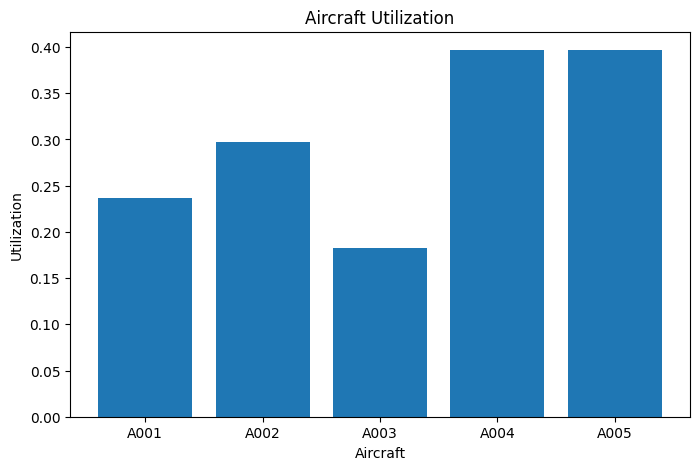

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

aircraft=pd.read_csv("../data/aircraft.csv")

sorties=pd.read_csv(
    "../data/sorties.csv",
    parse_dates=[
        "actual_start",
        "actual_end"
    ]
)

completed=sorties[
    sorties["status"]=="completed"
]

completed["actual_flown_hours"]=(
    completed["actual_end"]
    -
    completed["actual_start"]
).dt.total_seconds()/3600

flight_hours=(
    completed
    .groupby("aircraft_id")
    ["actual_flown_hours"]
    .sum()
    .reset_index()
)

aircraft_util=aircraft.merge(
    flight_hours,
    on="aircraft_id",
    how="left"
)

aircraft_util["actual_flown_hours"]=(
    aircraft_util[
        "actual_flown_hours"
    ].fillna(0)
)

aircraft_util["utilization"]=(
    aircraft_util[
        "actual_flown_hours"
    ]
    /
    aircraft_util[
        "total_available_hours"
    ]
)

plt.figure(figsize=(8,5))

plt.bar(
    aircraft_util["aircraft_id"],
    aircraft_util["utilization"]
)

plt.title(
    "Aircraft Utilization"
)

plt.xlabel(
    "Aircraft"
)

plt.ylabel(
    "Utilization"
)

plt.savefig(
    "../charts/aircraft_utilization.png"
)

plt.show()

## 2. Cancellation Reason Chart
Visualize main cancellation causes.

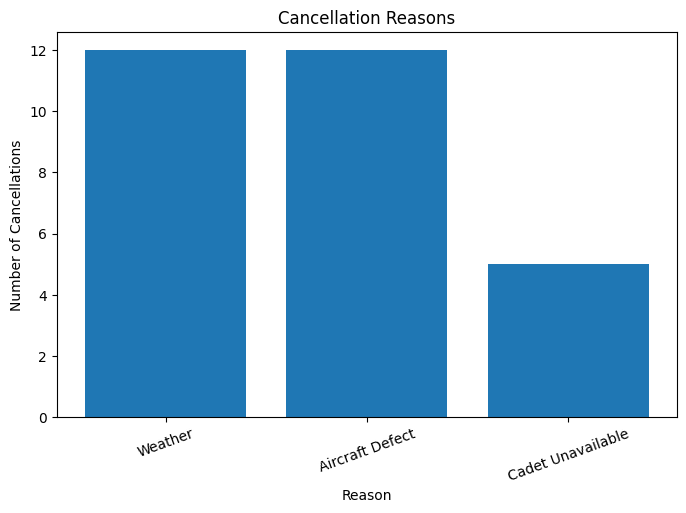

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

sorties=pd.read_csv(
    "../data/sorties.csv"
)

cancel_reason=(
    sorties[
        sorties["status"]=="cancelled"
    ]
    ["cancel_reason"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    cancel_reason.index,
    cancel_reason.values
)

plt.title(
    "Cancellation Reasons"
)

plt.xlabel(
    "Reason"
)

plt.ylabel(
    "Number of Cancellations"
)

plt.xticks(
    rotation=20
)

plt.savefig(
    "../charts/cancellation_reasons.png"
)

plt.show()

## 3. Cadet Flight Progress Chart

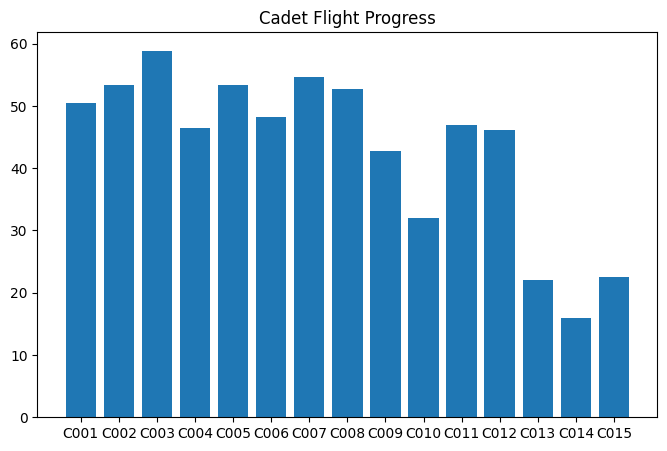

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

cadets=pd.read_csv("../data/cadets.csv")

cadets["progress"]=(
cadets["total_flown_hours"]
/
cadets["total_required_hours"]
)*100

plt.figure(figsize=(8,5))

plt.bar(
cadets["cadet_id"],
cadets["progress"]
)

plt.title(
"Cadet Flight Progress"
)

plt.savefig(
"../charts/cadet_progress.png"
)

plt.show()

## 4. TOGA Study Readiness Chart

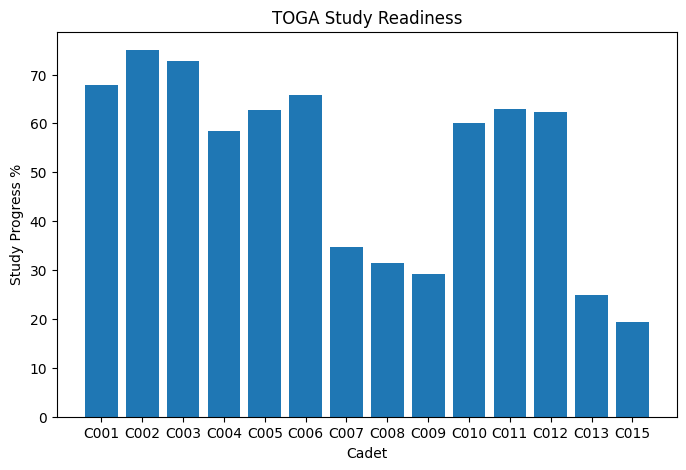

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

toga=pd.read_csv(
"../data/toga_study.csv"
)

study=toga.groupby(
"cadet_id"
).agg({
"chapters_completed":"sum",
"total_chapters":"sum"
}).reset_index()

study["study_progress"]=(
study["chapters_completed"]
/
study["total_chapters"]
)*100

plt.figure(figsize=(8,5))

plt.bar(
study["cadet_id"],
study["study_progress"]
)

plt.title(
"TOGA Study Readiness"
)

plt.xlabel(
"Cadet"
)

plt.ylabel(
"Study Progress %"
)

plt.savefig(
"../charts/study_readiness.png"
)

plt.show()

## 5. Outstanding Payment Chart

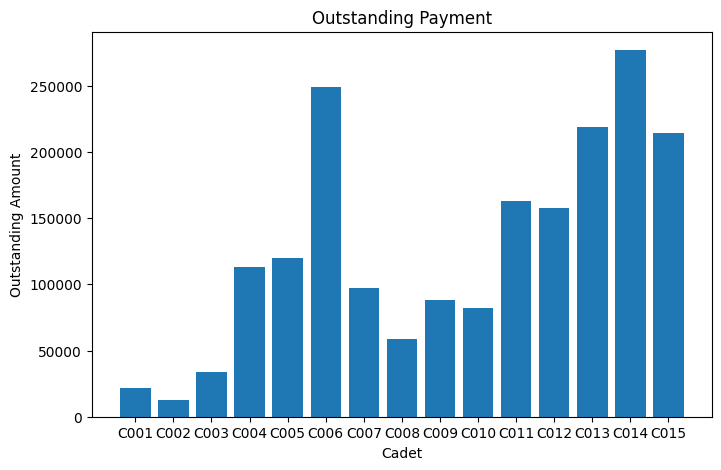

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

payments=pd.read_csv(
"../data/payments.csv"
)

payment_summary=payments.groupby(
"cadet_id"
)[
"outstanding_amount"
].sum()

plt.figure(figsize=(8,5))

plt.bar(
payment_summary.index,
payment_summary.values
)

plt.title(
"Outstanding Payment"
)

plt.xlabel(
"Cadet"
)

plt.ylabel(
"Outstanding Amount"
)

plt.savefig(
"../charts/payment_risk.png"
)

plt.show()

## 6. Cadet Risk Score Chart

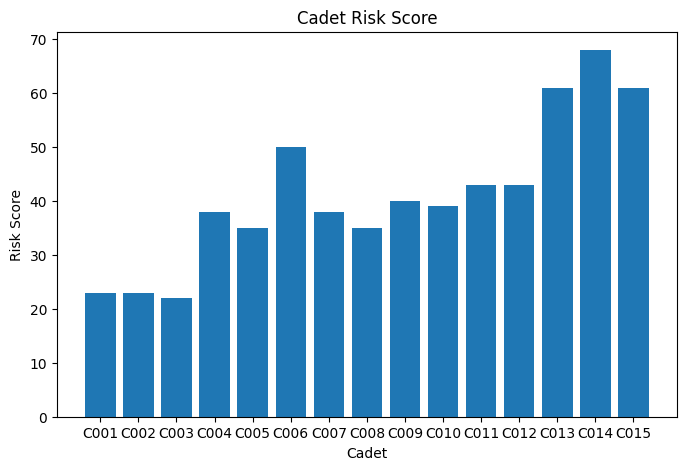

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

risk=pd.read_csv(
"../data/risk_scores.csv"
)

plt.figure(figsize=(8,5))

plt.bar(
risk["cadet_id"],
risk["risk_score"]
)

plt.title(
"Cadet Risk Score"
)

plt.xlabel(
"Cadet"
)

plt.ylabel(
"Risk Score"
)

plt.savefig(
"../charts/cadet_risk_scores.png"
)

plt.show()

## 7. Flight Progress vs Study Progress Scatter Plot

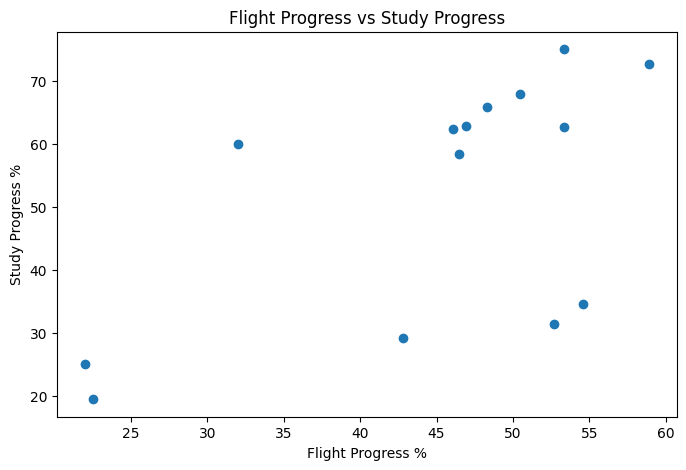

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

cadets=pd.read_csv(
"../data/cadets.csv"
)

toga=pd.read_csv(
"../data/toga_study.csv"
)

flight=cadets[
[
"cadet_id",
"total_flown_hours",
"total_required_hours"
]
].copy()

flight["flight_progress"]=(
flight["total_flown_hours"]
/
flight["total_required_hours"]
)*100


study=toga.groupby(
"cadet_id"
).agg({
"chapters_completed":"sum",
"total_chapters":"sum"
}).reset_index()

study["study_progress"]=(
study["chapters_completed"]
/
study["total_chapters"]
)*100


merged=flight.merge(
study,
on="cadet_id"
)

plt.figure(figsize=(8,5))

plt.scatter(
merged["flight_progress"],
merged["study_progress"]
)

plt.title(
"Flight Progress vs Study Progress"
)

plt.xlabel(
"Flight Progress %"
)

plt.ylabel(
"Study Progress %"
)

plt.savefig(
"../charts/flight_vs_study_progress.png"
)

plt.show()

# Generate Cleaned Output Dataset

In [20]:
import pandas as pd

cleaned_log=[]

def add_issue(
table,
issue,
count,
action
):
    cleaned_log.append([
        table,
        issue,
        count,
        action
    ])


add_issue(
"sorties",
"Invalid Dates",
2,
"Flagged for review"
)

add_issue(
"sorties",
"Completed Missing Times",
1,
"Filled as NULL"
)

add_issue(
"sorties",
"Delay Mismatch",
31,
"Delay recalculation required"
)

add_issue(
"payments",
"Payment Error",
1,
"Outstanding adjusted"
)

add_issue(
"toga_study",
"Study >100%",
1,
"Capped at 100%"
)

add_issue(
"aircraft",
"High Defects",
2,
"Marked operational review"
)

add_issue(
"cadets",
"No Study Activity",
1,
"Flagged for intervention"
)


cleaned_outputs=pd.DataFrame(
cleaned_log,
columns=[
"dataset",
"issue",
"affected_records",
"cleaning_action"
]
)

cleaned_outputs.to_csv(
"../data/cleaned_outputs.csv",
index=False
)

cleaned_outputs

,dataset,issue,affected_records,cleaning_action
0,sorties,Invalid Dates,2,Flagged for review
1,sorties,Completed Missing Times,1,Filled as NULL
2,sorties,Delay Mismatch,31,Delay recalculation required
3,payments,Payment Error,1,Outstanding adjusted
4,toga_study,Study >100%,1,Capped at 100%
5,aircraft,High Defects,2,Marked operational review
6,cadets,No Study Activity,1,Flagged for intervention


# Task 8 — Executive Insight Report

In [21]:
executive_report="""
# Executive Insight Report


## 1. Top 5 Operational Insights

1. Aircraft utilization varied significantly across bases, indicating uneven operational efficiency.

2. Certain aircraft showed elevated defect occurrence and require operational review.

3. Cancellation patterns were concentrated around a limited number of reasons.

4. Instructor allocation appeared imbalanced with potential workload bottlenecks.

5. Delay behaviour showed measurable impact on sortie completion.


## 2. Top 5 Training Progress Insights

1. Cadet progress rates varied considerably across the cohort.

2. Several cadets remain significantly below expected completion trajectory.

3. Lower study readiness frequently aligned with lower flight progress.

4. Instructor concentration may affect training throughput.

5. Progress variability indicates need for targeted intervention.


## 3. Top 3 TOGA Personalization Opportunities

1. Recommend adaptive study plans based on quiz performance.

2. Trigger reminders for cadets with declining study activity.

3. Personalize chapter sequencing based on training stage.


## 4. Top 3 Finance Risks

1. High outstanding balances may delay training completion.

2. Older payment activity correlates with continuity concerns.

3. Financial exposure should be monitored alongside training performance.


## 5. Product Recommendations for Skynet

1. Real-time operational utilization dashboard.

2. Automated aircraft risk monitoring.

3. Instructor workload balancing engine.


## 6. Product Recommendations for TOGA

1. Personalized readiness scoring.

2. Early intervention recommendation system.

3. Predictive study completion monitoring.


## 7. Data Quality Issues Found

1. Missing operational timestamps.

2. Delay mismatches.

3. Payment inconsistencies.

4. Study progress above logical limits.

5. Missing study activity.


## 8. Suggested Additional Data Fields

1. Weather severity index

2. Instructor feedback score

3. Cadet attendance score

4. Simulator hours

5. Study session duration

6. Recovery actions


## 9. Final Recommendation to AIRMAN Leadership

AIRMAN should combine operational, training, study, and financial intelligence into one explainable monitoring layer. Early intervention and transparent risk communication are recommended over reactive management.
"""

with open(
"../reports/executive_insights.md",
"w",
encoding="utf-8"
) as f:

    f.write(
        executive_report
    )

print(
"executive_insights.md created"
)

executive_insights.md created
